# IMAGE COLORIZATION — U-NET (LAB VERSION)

Goal:
Train a neural network that converts grayscale images into color images.

Task:
- Input: grayscale image
- Output: color image

Improvement over baseline:
- We use LAB color space instead of RGB
- Model predicts only A and B channels (color information)
- L channel (lightness) is used as input

## 0. IMPORTS

In [53]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

from skimage.color import rgb2lab, lab2rgb


os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE' # This fixes the OpenMP kernel crash!

# The Ultimate Hardware Detector
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(" NVIDIA GPU Detected! Using CUDA.")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print(" Apple Silicon Detected! Using MPS.")
else:
    try:
        import torch_directml
        if torch_directml.is_available():
            device = torch_directml.device()
            print(" AMD/Windows GPU Detected! Using DirectML.")
        else:
            raise ImportError
    except ImportError:
        device = torch.device("cpu")
        print(" No recognized GPU found. Falling back to CPU. (This will be slow!)")

 NVIDIA GPU Detected! Using CUDA.


## 1. Dataset

    Converts RGB images → LAB color space.

    Input:
        L channel (grayscale-like, lightness)
    Target:
        AB channels (color information)

In [54]:
class ColorizationDatasetLAB(Dataset):
    def __init__(self, root_dir, size=128, limit=None):
        exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
        paths = [f for f in os.listdir(root_dir)
                 if os.path.splitext(f)[1].lower() in exts]
        if limit:
            paths = paths[:limit]

        self.paths = [os.path.join(root_dir, p) for p in paths]
        self.size = size
        self.tf = transforms.Compose([
            transforms.Resize((size, size))
        ])

    def __len__(self):
        return len(self.paths)

   
    def __getitem__(self, idx):
        # Load image
        img = Image.open(self.paths[idx]).convert("RGB")
        img = self.tf(img)
        # Convert to numpy
        img = np.array(img).astype(np.float32) / 255.0

        # RGB → LAB conversion
        lab = rgb2lab(img).astype(np.float32)

        # Normalize L to [-1, 1]
        L = lab[:, :, 0] / 50.0 - 1.0

        # Normalize AB to [-1, 1]
        AB = lab[:, :, 1:] / 128.0

        # Convert to tensors
        L = torch.from_numpy(L).unsqueeze(0)
        AB = torch.from_numpy(AB).permute(2, 0, 1)

        return L, AB

## 2. DataLoader +  DATA SPLIT
 

In [55]:
ROOT_DIR = "data/images"
IMG_SIZE = 128
LIMIT = 4000
BATCH = 32

full_dataset = ColorizationDatasetLAB(ROOT_DIR, IMG_SIZE, LIMIT)

train_size = int(0.8 * len(full_dataset))
val_size   = int(0.1 * len(full_dataset))
test_size  = len(full_dataset) - train_size - val_size

train_ds, val_ds, test_ds = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH, shuffle=False)

print(len(train_ds), len(val_ds), len(test_ds))

3200 400 400


## 3. check one example (INPUT vs OUTPUT SPACE) 

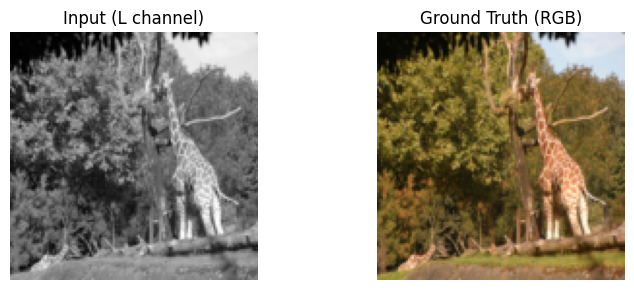

In [56]:
L, AB = full_dataset[0]
L_np = L.squeeze().numpy()
AB_np = AB.permute(1, 2, 0).numpy()

# Reconstruct LAB image for visualization
lab = np.zeros((IMG_SIZE, IMG_SIZE, 3))
lab[:, :, 0] = (L_np + 1.0) * 50
lab[:, :, 1:] = AB_np * 128

rgb = lab2rgb(lab)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

axes[0].imshow(L_np, cmap="gray")
axes[0].set_title("Input (L channel)")

axes[1].imshow(rgb)
axes[1].set_title("Ground Truth (RGB)")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()


## 4.  MODEL — U-Net

Architecture:
Encoder-decoder with skip connections (U-Net)
Input: 1 channel (L)
Output: 2 channels (A, B)

In [57]:
def conv_block(in_c, out_c):
    return nn.Sequential(
        nn.Conv2d(in_c, out_c, 3, padding=1), nn.ReLU(inplace=True),
        nn.Conv2d(out_c, out_c, 3, padding=1), nn.ReLU(inplace=True)
    )

class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = conv_block(1, 64)
        self.enc2 = conv_block(64, 128)
        self.pool = nn.MaxPool2d(2)

        self.mid = conv_block(128, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.dec2 = conv_block(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec1 = conv_block(128, 64)

        self.out = nn.Conv2d(64, 2, 1)  # AB channels

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        m = self.mid(self.pool(e2))

        d2 = self.dec2(torch.cat([self.up2(m), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return torch.tanh(self.out(d1))

model = UNet().to(device)

## 5. LOSS FUNCTION


In [58]:
# L1 loss is better than MSE for image generation

criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

## 6. Learning

In [59]:
EPOCHS = 10
history = []

for epoch in range(EPOCHS):
    model.train()
    total = 0

    for L, ab in train_loader:
        L, ab = L.to(device), ab.to(device)

        pred = model(L)
        loss = criterion(pred, ab)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total += loss.item()

    avg = total / len(train_loader)
    history.append(avg)
    print(f"Epoch {epoch+1}: {avg:.4f}")

Epoch 1: 0.0740
Epoch 2: 0.0723
Epoch 3: 0.0722
Epoch 4: 0.0720
Epoch 5: 0.0720
Epoch 6: 0.0719
Epoch 7: 0.0718
Epoch 8: 0.0718
Epoch 9: 0.0717
Epoch 10: 0.0716


In [60]:
model.eval()
val_loss = 0

with torch.no_grad():
    for L, ab in val_loader:
        L, ab = L.to(device), ab.to(device)
        pred = model(L)
        loss = criterion(pred, ab)
        val_loss += loss.item()

print("Validation Loss:", val_loss / len(val_loader))

Validation Loss: 0.06943293947439927


## 7. SAVE MODEL


In [61]:
torch.save(model.state_dict(), "unet_lab.pth")


## 8. The graph of model

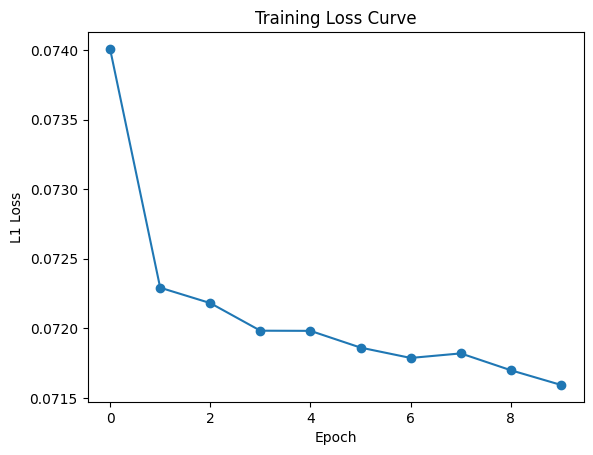

In [70]:
plt.plot(history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("L1 Loss")
plt.title("Training Loss Curve")
plt.show()


## 9. vizualing model

Shows:
- Input (L)
- Predicted color image
- Ground truth image



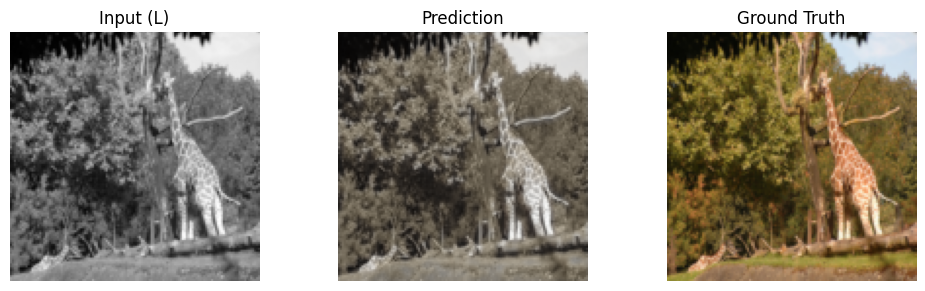

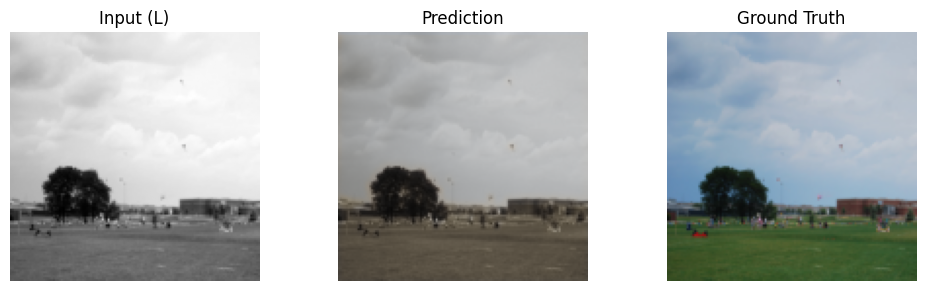

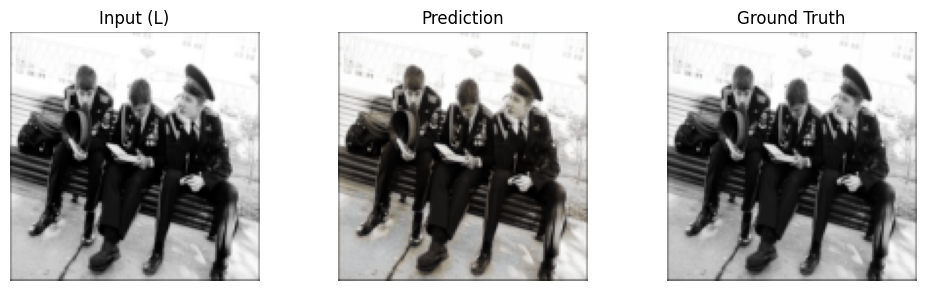

In [69]:
def visualize(idx, dataset):
    model.eval()

    L, ab = dataset[idx]

    with torch.no_grad():
        pred_ab = model(L.unsqueeze(0).to(device)).cpu().squeeze()

    # --- torch → numpy ONLY at the end ---
    L_np = L.squeeze().numpy()
    ab_np = ab.permute(1,2,0).numpy()
    pred_np = pred_ab.permute(1,2,0).numpy()

    pred_np = np.clip(pred_np, -1, 1)

    # --- LAB reconstruction ---
    lab_pred = np.zeros((L_np.shape[0], L_np.shape[1], 3))
    lab_true = np.zeros_like(lab_pred)

    lab_pred[:,:,0] = (L_np + 1.0) * 50
    lab_true[:,:,0] = (L_np + 1.0) * 50

    lab_pred[:,:,1:] = pred_np * 128
    lab_true[:,:,1:] = ab_np * 128

    img_pred = lab2rgb(lab_pred)
    img_true = lab2rgb(lab_true)

    # --- plot ---
    fig, ax = plt.subplots(1,3, figsize=(10,3))

    ax[0].imshow(L_np, cmap='gray')
    ax[0].set_title("Input (L)")

    ax[1].imshow(img_pred)
    ax[1].set_title("Prediction")

    ax[2].imshow(img_true)
    ax[2].set_title("Ground Truth")

    for a in ax:
        a.axis("off")

    plt.tight_layout()
    plt.show()

for i in [0,5,10]:
    visualize(i, full_dataset)

## 10. Comparison summary:

RGB approach (baseline / less optimal)

In the RGB-based approach, the model is trained to directly predict all three color channels (R, G, B) at the same time.
This means the network must learn both image structure (brightness, edges) and color information simultaneously, which increases the complexity of the task.

Main limitations:

The model mixes brightness and color information in a single representation
Learning becomes harder because channels are highly correlated
Outputs often look blurry or desaturated
Less stable training behavior compared to structured color spaces
LAB approach (improved method)

In the LAB color space approach, the problem is reformulated:

The L channel (lightness) is given as input (grayscale structure)
The model only predicts the A and B channels (color information)

This separation significantly simplifies the learning task.

Advantages:

The structure of the image (edges, shapes, brightness) is already preserved in L
The model focuses only on learning colorization patterns
Training is more stable and efficient
Generated images usually have more realistic and vivid colors